In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import scene_generation.core as core_mod
import time

from pathlib import Path
from scene_generation.core import Scene
from scene_generation.utils import rect_from_point_and_size
from collections import Counter
from matplotlib.patches import Patch
from PIL import Image, ImageDraw
from sionna.rt import scene, preview

In [16]:
# Scene center (only need to update CENTER_LON, CENTER_LAT, DATA_DIR_LIDAR_OSM, DATA_DIR_OVERTURE and run the rest of the cells to receive full analysis)
# DuPont Circle: -77.043446, 38.909647
# Duke Wilkinson area: -78.940297, 36.002556
# Flatiron Building: -73.9897, 40.7411
CENTER_LON = -73.9897
CENTER_LAT  = 40.7411

SCENE_WIDTH  = 500   # east–west extent, metres
SCENE_HEIGHT = 500   # north–south extent, metres

DATA_DIR_LIDAR_OSM = "./scenes/flatiron_lidar_osm"
DATA_DIR_OVERTURE = "./scenes/flatiron_overture"

OSM_SERVER = "https://overpass-api.de/api/interpreter"

In [17]:
for out_dir in (DATA_DIR_LIDAR_OSM, DATA_DIR_OVERTURE):
    os.makedirs(out_dir, exist_ok=True)
    print(f"Output directory: {os.path.abspath(out_dir)}")

Output directory: /home/rt279/geo2sigmap-fork/research/examples/scenes/flatiron_lidar_osm
Output directory: /home/rt279/geo2sigmap-fork/research/examples/scenes/flatiron_overture


Loading local 3DEP dataset polygons...
Done. 3DEP polygons downloaded and projected to  EPSG:32618
Area of Interest: POLYGON ((-8236995.756342295 4973738.096657826, -8236984.41032669 4974730.634115181, -8235995.666205104 4974719.209260046, -8236007.078885074 4973726.674766785, -8236995.756342295 4973738.096657826))
Found 1 intersecting datasets
Successfully generated HAG data


Parsing buildings: 100%|██████████| 275/275 [00:02<00:00, 97.93it/s] 


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Parsing buildings: 100%|██████████| 272/272 [00:00<00:00, 536.27it/s]

Scene generation complete!


,mode,runtime_seconds,relative_to_lidar_osm
0,lidar-osm,13.341,1.00
1,overture,17.870,1.34


,mode,height_source,building_count,building_percentage
0,lidar-osm,hag,271,99.63%
1,lidar-osm,osm:height,1,0.37%
2,overture,overture:height,267,98.16%
3,overture,fallback:random,4,1.47%
4,overture,overture:levels,1,0.37%


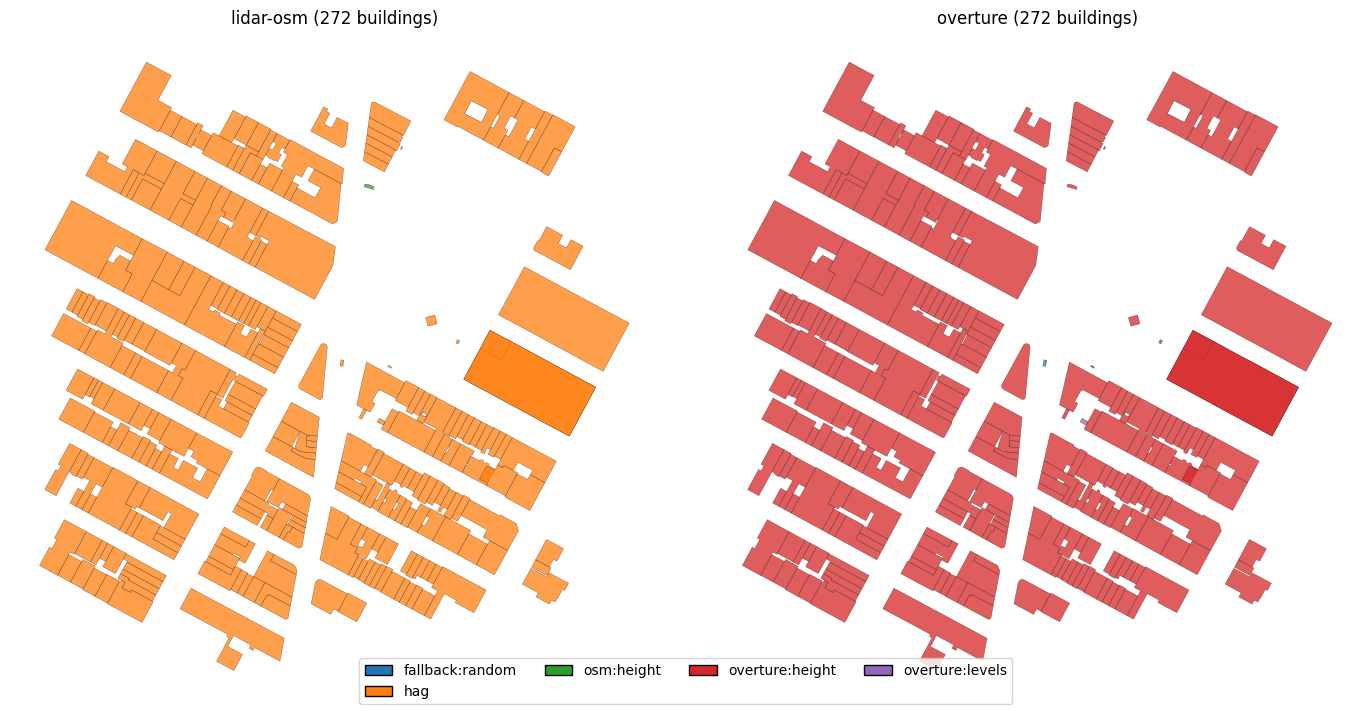

LiDAR HAG raster exists : True


In [18]:
def summarize_height_sources(mode, height_sources):
    """Summarize counts and percentages of buildings by selected height source."""
    total_buildings = sum(height_sources.values())
    rows = []

    for source, building_count in height_sources.most_common():
        building_percentage = (
            (building_count / total_buildings) * 100 if total_buildings else 0.0
        )
        rows.append(
            {
                "mode": mode,
                "height_source": source,
                "building_count": building_count,
                "building_percentage": f"{building_percentage:.2f}%",
            }
        )

    return pd.DataFrame(
        rows,
        columns=["mode", "height_source", "building_count", "building_percentage"],
    )


def iter_polygons(geometry):
    """Yield polygon parts from a Shapely Polygon or MultiPolygon."""
    if geometry is None or geometry.is_empty:
        return

    if geometry.geom_type == "Polygon":
        yield geometry
    elif geometry.geom_type == "MultiPolygon":
        yield from geometry.geoms


def plot_height_source_footprints(
    lidar_records, overture_records, *, figsize=(14, 7), alpha=0.75
):
    """Plot building footprints for both modes, colored by height source."""
    mode_records = [
        ("lidar-osm", lidar_records),
        ("overture", overture_records),
    ]
    all_sources = sorted(
        {
            record["height_source"]
            for _, records in mode_records
            for record in records
        }
    )
    cmap = plt.get_cmap("tab10")
    source_colors = {
        source: cmap(index % cmap.N) for index, source in enumerate(all_sources)
    }

    fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)
    for ax, (mode, records) in zip(axes, mode_records):
        for record in records:
            source = record["height_source"]
            for polygon in iter_polygons(record["footprint"]):
                x, y = polygon.exterior.xy
                ax.fill(
                    x,
                    y,
                    facecolor=source_colors[source],
                    edgecolor="black",
                    linewidth=0.2,
                    alpha=alpha,
                )
                for interior in polygon.interiors:
                    hole_x, hole_y = interior.xy
                    ax.fill(
                        hole_x,
                        hole_y,
                        facecolor="white",
                        edgecolor="black",
                        linewidth=0.2,
                    )

        ax.set_title(f"{mode} ({len(records)} buildings)")
        ax.set_aspect("equal", adjustable="box")
        ax.axis("off")

    legend_handles = [
        Patch(facecolor=color, edgecolor="black", label=source)
        for source, color in source_colors.items()
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=max(1, min(4, len(legend_handles))),
    )
    return fig, axes


def rasterize_height_source_mask(records, height_source, shape, ground_bounds):
    """Rasterize footprints for one height source onto a building-map grid."""
    min_x, _, _, max_y = ground_bounds
    mask_image = Image.new("1", (shape[1], shape[0]), 0)
    draw = ImageDraw.Draw(mask_image)

    for record in records:
        if record["height_source"] != height_source:
            continue

        for polygon in iter_polygons(record["footprint"]):
            pixel_coords = [(x - min_x, max_y - y) for x, y in polygon.exterior.coords]
            draw.polygon(pixel_coords, outline=1, fill=1)

    return np.array(mask_image, dtype=bool)


def generate_scene(mode, out_dir, *, track_height_sources=False):
    """Generate the scene and optionally count selected height sources."""
    scene_polygon = rect_from_point_and_size(
    CENTER_LON, CENTER_LAT, "center", SCENE_WIDTH, SCENE_HEIGHT
    )

    height_sources = []
    height_source_records = []
    original_resolve = core_mod.resolve_building_height

    def logging_resolve_building_height(*args, **kwargs):
        kwargs = dict(kwargs)
        kwargs["return_source"] = True
        height, metadata = original_resolve(*args, **kwargs)
        source = metadata.get("source", "unknown")
        footprint = args[1] if len(args) > 1 else kwargs.get("building_polygon")
        height_sources.append(source)
        height_source_records.append(
            {
                "mode": mode,
                "height_source": source,
                "height_m": height,
                "footprint": footprint,
            }
        )
        return height

    if track_height_sources:
        core_mod.resolve_building_height = logging_resolve_building_height

    try:
        scene = Scene()
        building_height_map = scene(
            points=scene_polygon,
            data_dir=out_dir,
            osm_server_addr=OSM_SERVER,
            hag_tiff_path=None,  # None lets lidar-osm create/reuse out_dir/test_hag.tif
            ground_material_type="mat-itu_wet_ground",
            rooftop_material_type="mat-itu_metal",
            wall_material_type="mat-itu_concrete",
            generate_building_map=True,
            building_height_mode=mode,
            # lidar_terrain=False,
            # dem_terrain=False,
        )
        ground_bounds = scene._ground_polygon_envelope_UTM.bounds
    finally:
        if track_height_sources:
            core_mod.resolve_building_height = original_resolve

    return building_height_map, Counter(height_sources), height_source_records, ground_bounds

scene_generation_runtimes = []

start_time = time.perf_counter()
lidar_height_map, lidar_height_sources, lidar_height_source_records, lidar_ground_bounds = generate_scene(
    "lidar-osm", DATA_DIR_LIDAR_OSM, track_height_sources=True
)
scene_generation_runtimes.append(
    {"mode": "lidar-osm", "runtime_seconds": time.perf_counter() - start_time}
)

start_time = time.perf_counter()
overture_height_map, overture_height_sources, overture_height_source_records, overture_ground_bounds = generate_scene(
    "overture", DATA_DIR_OVERTURE, track_height_sources=True
)
scene_generation_runtimes.append(
    {"mode": "overture", "runtime_seconds": time.perf_counter() - start_time}
)

print("Scene generation complete!")
scene_generation_runtime_summary = pd.DataFrame(scene_generation_runtimes)
lidar_runtime_seconds = scene_generation_runtime_summary.loc[
    scene_generation_runtime_summary["mode"] == "lidar-osm",
    "runtime_seconds",
].iloc[0]
scene_generation_runtime_summary["runtime_seconds"] = scene_generation_runtime_summary[
    "runtime_seconds"
].round(3)
scene_generation_runtime_summary["relative_to_lidar_osm"] = (
    scene_generation_runtime_summary["runtime_seconds"] / lidar_runtime_seconds
).round(2)
display(scene_generation_runtime_summary)

height_source_summary = pd.concat(
    [
        summarize_height_sources("lidar-osm", lidar_height_sources),
        summarize_height_sources("overture", overture_height_sources),
    ],
    ignore_index=True,
)
display(height_source_summary)
plot_height_source_footprints(lidar_height_source_records, overture_height_source_records)
plt.show()
print("LiDAR HAG raster exists :", (Path(DATA_DIR_LIDAR_OSM) / "test_hag.tif").exists())

,check,value
0,same raster,False
1,mean abs diff on building pixels (m),15.351
2,max abs diff (m),218.0
3,LiDAR HAG pixels outside Overture explicit height,105


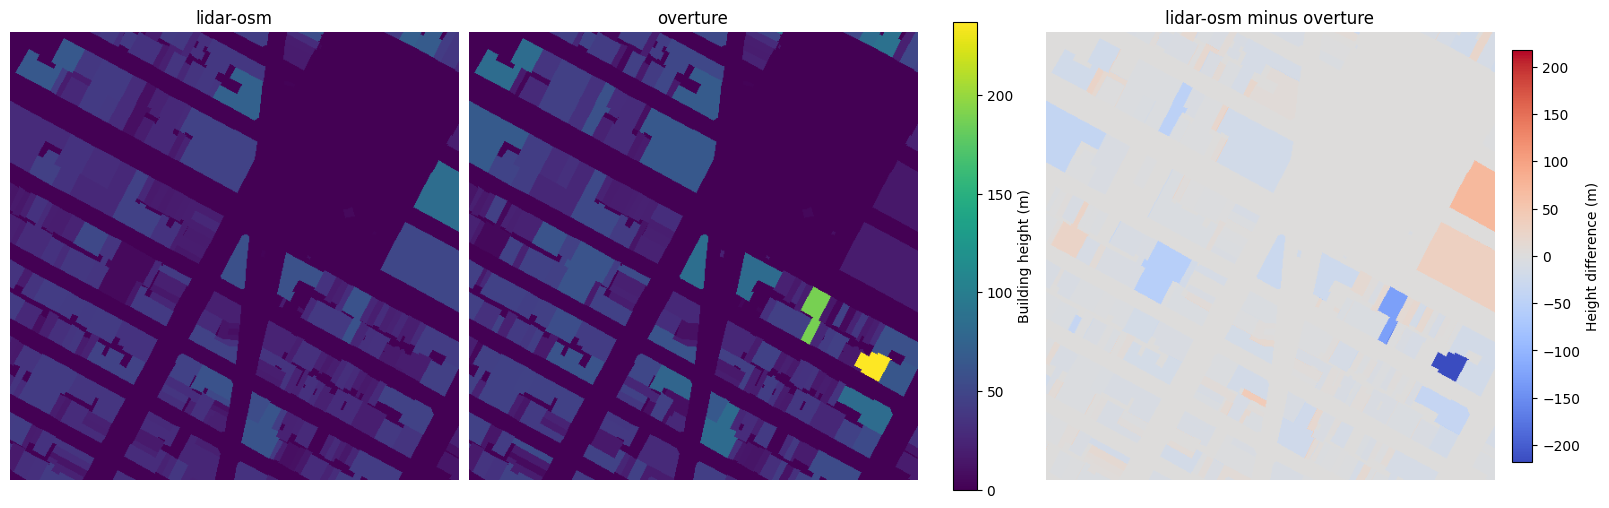

In [19]:
# Compare final building-height maps from the two modes.
lidar_map = np.load(Path(DATA_DIR_LIDAR_OSM) / "2D_Building_Height_Map.npy")
overture_map = np.load(Path(DATA_DIR_OVERTURE) / "2D_Building_Height_Map.npy")

diff = lidar_map.astype(float) - overture_map.astype(float)
building_mask = (lidar_map > 0) | (overture_map > 0)
mean_abs_diff = np.mean(np.abs(diff[building_mask])) if building_mask.any() else 0.0
max_abs_diff = np.max(np.abs(diff)) if diff.size else 0.0
lidar_hag_mask = rasterize_height_source_mask(
    lidar_height_source_records,
    "hag",
    lidar_map.shape,
    lidar_ground_bounds,
)
overture_explicit_height_mask = rasterize_height_source_mask(
    overture_height_source_records,
    "overture:height",
    lidar_map.shape,
    overture_ground_bounds,
)
lidar_hag_not_overture_explicit_height_pixels = int(
    np.count_nonzero(lidar_hag_mask & ~overture_explicit_height_mask)
)

comparison = pd.DataFrame(
    [
        ("same raster", np.array_equal(lidar_map, overture_map)),
        ("mean abs diff on building pixels (m)", round(float(mean_abs_diff), 3)),
        ("max abs diff (m)", round(float(max_abs_diff), 3)),
        (
            "LiDAR HAG pixels outside Overture explicit height",
            lidar_hag_not_overture_explicit_height_pixels,
        ),
    ],
    columns=["check", "value"],
)
display(comparison)

height_vmax = max(float(lidar_map.max()), float(overture_map.max()), 1.0)
diff_abs_max = max(float(np.max(np.abs(diff))), 1.0) if diff.size else 1.0

fig, axs = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
height_im = axs[0].imshow(lidar_map, cmap="viridis", vmin=0, vmax=height_vmax)
axs[0].set_title("lidar-osm")
axs[1].imshow(overture_map, cmap="viridis", vmin=0, vmax=height_vmax)
axs[1].set_title("overture")
diff_im = axs[2].imshow(diff, cmap="coolwarm", vmin=-diff_abs_max, vmax=diff_abs_max)
axs[2].set_title("lidar-osm minus overture")
height_cbar = fig.colorbar(height_im, ax=axs[:2], fraction=0.046, pad=0.04)
height_cbar.set_label("Building height (m)")
diff_cbar = fig.colorbar(diff_im, ax=axs[2], fraction=0.046, pad=0.04)
diff_cbar.set_label("Height difference (m)")
for ax in axs:
    ax.axis("off")
plt.show()

In [20]:

lidar_osm_sionna_scene = scene.load_scene(DATA_DIR_LIDAR_OSM + "/scene.xml")
lidar_osm_sionna_scene.preview()

2026-06-12 11:45:08 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).


In [21]:
overture_sionna_scene = scene.load_scene(DATA_DIR_OVERTURE + "/scene.xml")
overture_sionna_scene.preview()

2026-06-12 11:45:09 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).
